In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import *
import scipy
import h5py
from scipy.fft import *
from nbodykit.lab import *

In [2]:
lhid=0
grid = 128
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/128])
MAS='CIC'
MAS_index=2

pos_target = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
# pos_target=high_res_pos(pos_target, n=2)
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype(np.float32)
# pos=pos-0.5*BoxSize/128.
pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos = NGP(pos, grid, BoxSize)
acc = pos_target-pos
pos = pos%BoxSize
np.random.seed(0)
# pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)
# Lnoise = (1000/128)/np.sqrt(3)  # Set by CHARM resolution
# pos += np.random.randn(*pos.shape) * Lnoise
# pos=high_res_pos(pos, n=2)
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)




Using CIC mass assignment scheme
Time taken = 0.007 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.10 seconds

Using CIC mass assignment scheme
Time taken = 0.005 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


In [ ]:
plt.loglog(h5py.File("/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/0/diag/halos.h5")['0.666667']['Pk'][()][:,0])
plt.plot(Pk0, ':', label='fastpm')

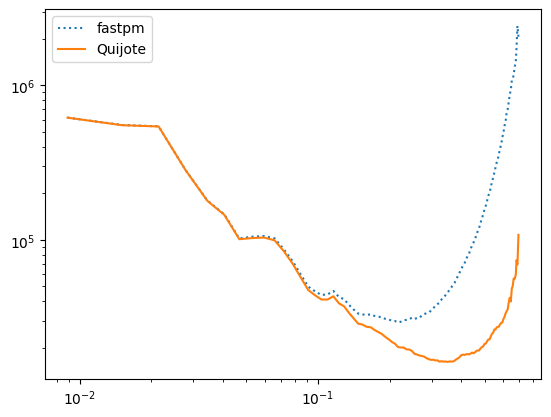

In [3]:
plt.plot(k, Pk0, ':', label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.loglog()
plt.legend()

In [3]:
Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize)
# Qk=np.abs(Qk)
Qk[Qk<0]=0

## Method 1: get phi from Q(k) using Pylians

In [52]:
phi = get_phi(k, Qk, grid=grid, BoxSize=BoxSize, Rayleigh_sampling=0)
a_x, a_y, a_z = calculate_acc(phi, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta_corrected=get_delta(pos=pos_corrected, grid=128, W=0, mass=1, BoxSize=1000., MAS='CIC', verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=1000., MAS='CIC', axis=0, verbose=True)

delta(k) field generated
time taken = 0.11742 seconds


Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.03
Time taken = 0.06 seconds


/home/x-abairagi/Projects/Power-Spectrum-Change-Under-Gradient-Perturbation/funcs.py:244: RuntimeWarning: invalid value encountered in cast
  d = grid_pos - i0  # Fractional offset in cell


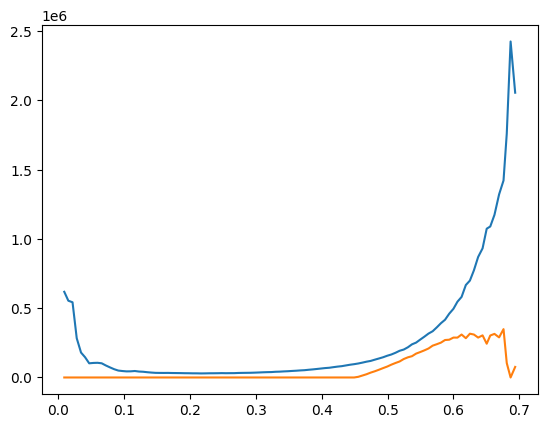

In [53]:
plt.plot(k,Pk0, label='fastpm')
plt.plot(k,k**4*Qk, label='Q(k)')

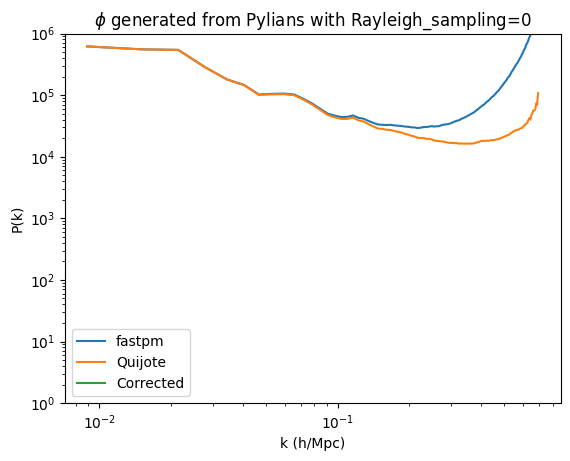

In [54]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\phi$ generated from Pylians with Rayleigh_sampling=0")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,1000000])
plt.legend()

## Method 2: get phi from Q(k) using sqrt(Q/P)delta

In [4]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta_k = fftshift(fftn(delta))
MAS_index=2
rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
binlist = np.linspace(rad.min(), rad.max(), len(k))
index = np.digitize(rad, binlist)-1

weights = np.sqrt(Qk/Pk0)
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


In [5]:
Pk0_corrected

array([603768.32112153, 517445.41956055, 475036.2882781 , 227298.04661854,
       132537.3980823 ,  94943.41348006,  60837.71518736,  57689.51315633,
        52347.03313852,  46540.99512723,  36009.8672907 ,  29084.53394374,
        22533.38560626,  20247.88712709,  18154.01379321,  17234.17674229,
        17822.98074236,  17763.15654636,  17224.4132022 ,  17019.5957961 ,
        15836.94264482,  15723.23477261,  15554.31350711,  15357.60436288,
        14755.55982871,  14847.28880318,  14709.48883169,  14774.90563595,
        14788.91843983,  14552.73596341,  14609.38046071,  14586.52856237,
        14507.57309604,  14450.55589498,  14413.1161829 ,  14513.61686831,
        14472.75645767,  14434.00822134,  14494.69398956,  14639.97185447,
        14530.09749408,  14716.83088206,  14600.62263597,  14605.5116937 ,
        14707.09507542,  14725.27333134,  15008.22376507,  15002.6106104 ,
        14865.08069885,  15137.82966691,  15276.87207892,  15339.89467805,
        15569.44447038,  

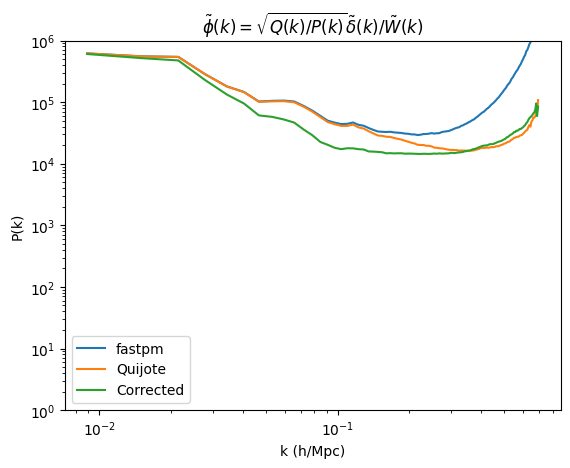

In [6]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("$\\tilde{\phi}(k)=\sqrt{Q(k)/P(k)}\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([1,1e6])
plt.legend()

In [7]:
acc_partpos=acc_at_particle_pos(pos, a_x, a_y, a_z, grid, BoxSize)

In [8]:
acc_partpos.min()

-780981.06

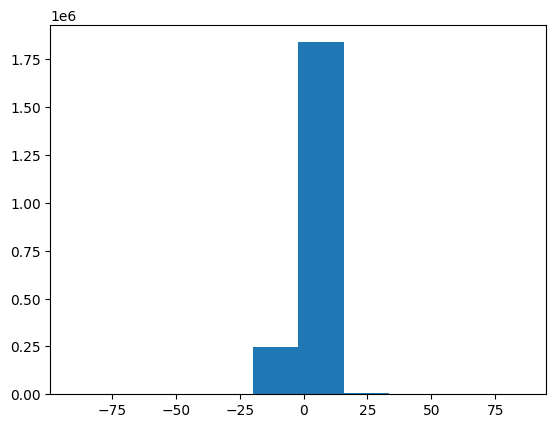

In [77]:
plt.hist(a_x.flatten()*128/1024,10);

[]

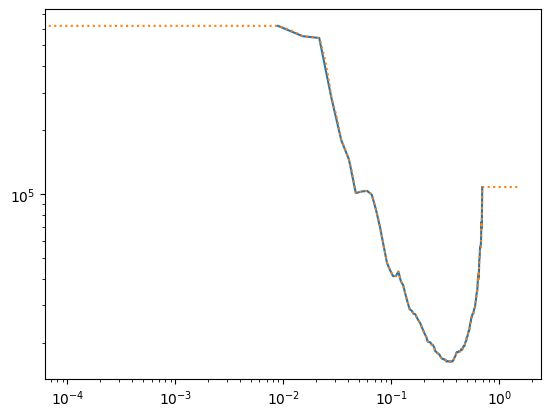

In [93]:
k_in=np.arange(0,1.5, 0.0001)
plt.plot(k, Pk0_target)
plt.plot(k_in, np.interp(k_in, k, Pk0_target), ":")
plt.loglog()

In [50]:
def get_iterative_perturb_pos(k, Pk0, Pk0_target, grid=128, BoxSize=1000., iteration=3):
    for it in range(iteration):
        Qk = calculate_Qk(k, Pk0, Pk0_target, BoxSize=BoxSize)
        Qk=np.abs(Qk)
        # Qk[Qk<0]=0
        phi = get_phi(k, Qk, grid=grid, BoxSize=BoxSize)
        a_x, a_y, a_z = calculate_acc(phi, grid=grid, BoxSize=BoxSize)
        pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)
        
        delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS='CIC', verbose=True)
        k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS='CIC', axis=0, verbose=True)
        plt.loglog(k_corrected, Pk0_corrected, label=f'Corrected-{it}')
        k, Pk0 = k_corrected, Pk0_corrected
    plt.show()
    plt.legend()
    

In [ ]:
get_iterative_perturb_pos(k, Pk0, Pk0_target, grid=128, BoxSize=1000., iteration=2)
